In [2]:
%matplotlib inline
import sys
import yaml
from IPython.display import Code
import pcse
from datetime import datetime, timedelta
import pprint
import pandas as pd
import numpy as np
import matplotlib
matplotlib.style.use("ggplot")
import matplotlib.pyplot as plt
import os
import xarray as xr
import pickle
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import re

/Users/nadiatestani/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
# Open data files

show_climate = False
crop = 'Spring_Wheat'
loc = 'Foulum'
rcp = '45'
climateperiod = '2041_2070'

#base scenario parameters
co2_base = 380
SD_base = 'may10'
fert_base = 140

#data scenario parameters
co2_data = 380
SD_data = 'may10'
fert_data = 140


In [8]:

# File paths data
file1_data = f"simulations/Denmark BADM9024_{co2_data}ppm_SD{SD_data}_Fert{fert_data}.csv"

# File paths base
file1_base = f"simulations/Denmark BADM9024_{co2_base}ppm_SD{SD_base}_Fert{fert_base}.csv"

# Load CSV with climate model mean changes
# CSV has columns: model_name, t_change, pp_change
df_changes = pd.read_csv(f"methodology_outs/rcp{rcp}_{climateperiod}_meanChanges_{loc}.csv")

In [9]:
# Read CSV file with data - no rows skipped
def read_excel_files(file_path):
    # Read CSV file with no rows skipped
    df = pd.read_csv(file_path)
    
    # Extract year from PDAT (YYYYMMDD format) to create HYEAR
    df['HYEAR'] = df['PDAT'].astype(str).str[:4].astype(int)
    
    # Rename columns: Temperature -> Tstep, Precipitation -> PPstep
    df = df.rename(columns={
        'Temperature': 'Tstep',
        'Precipitation': 'PPstep'
    })
    
    # Select and reorder columns as required
    df_simulations = df[['HWAM', 'Tstep', 'PPstep', 'HYEAR']]
    
    # Convert Tstep and PPstep to numeric
    df_simulations['Tstep'] = pd.to_numeric(df_simulations['Tstep'], errors='coerce')
    df_simulations['PPstep'] = pd.to_numeric(df_simulations['PPstep'], errors='coerce')
    
    return df_simulations

In [10]:
def wso_cube_from_results(df_simulations):
    # 1) Get unique coordinates from the DataFrame
    years = sorted(df_simulations['HYEAR'].unique())
    tsteps = sorted(df_simulations['Tstep'].dropna().unique())
    ppsteps = sorted(df_simulations['PPstep'].dropna().unique())

    # 2) Initialize empty DataArray (year, Tstep, PPstep)
    WSO = xr.DataArray(
        np.full((len(years), len(ppsteps), len(tsteps)), np.nan, dtype=float),
        dims=("year", "PPstep", "Tstep"),
        coords={"year": years, "PPstep": ppsteps, "Tstep": tsteps},
        name="WSO",
    )

    # 3) Fill values from DataFrame
    for _, row in df_simulations.iterrows():
        year = row['HYEAR']
        tstep = row['Tstep']
        ppstep = row['PPstep']
        hwam = row['HWAM']
        
        if pd.notna(year) and pd.notna(tstep) and pd.notna(ppstep) and pd.notna(hwam):
            WSO.loc[dict(year=year, Tstep=tstep, PPstep=ppstep)] = hwam

    # 4) Return as Dataset for saving convenience
    return xr.Dataset({"WSO": WSO})

In [11]:
df_data = read_excel_files(file1_data)
wsoIRS = wso_cube_from_results(df_data)
WSO_max = wsoIRS['WSO']

df_base = read_excel_files(file1_base)
wsoBase = wso_cube_from_results(df_base)
WSO_max_base = wsoBase['WSO']

/var/folders/hh/pldtd_756y10knrbjp0j8jv80000gn/T/ipykernel_59603/2432568553.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_simulations['Tstep'] = pd.to_numeric(df_simulations['Tstep'], errors='coerce')
/var/folders/hh/pldtd_756y10knrbjp0j8jv80000gn/T/ipykernel_59603/2432568553.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_simulations['PPstep'] = pd.to_numeric(df_simulations['PPstep'], errors='coerce')
/var/folders/hh/pldtd_756y10knrbjp0j8jv80000gn/T/ipykernel_59603/2432568553.py:19: Setti

Text(0.5, 1.0, 'Foulum yield, Dif = 105.53%')

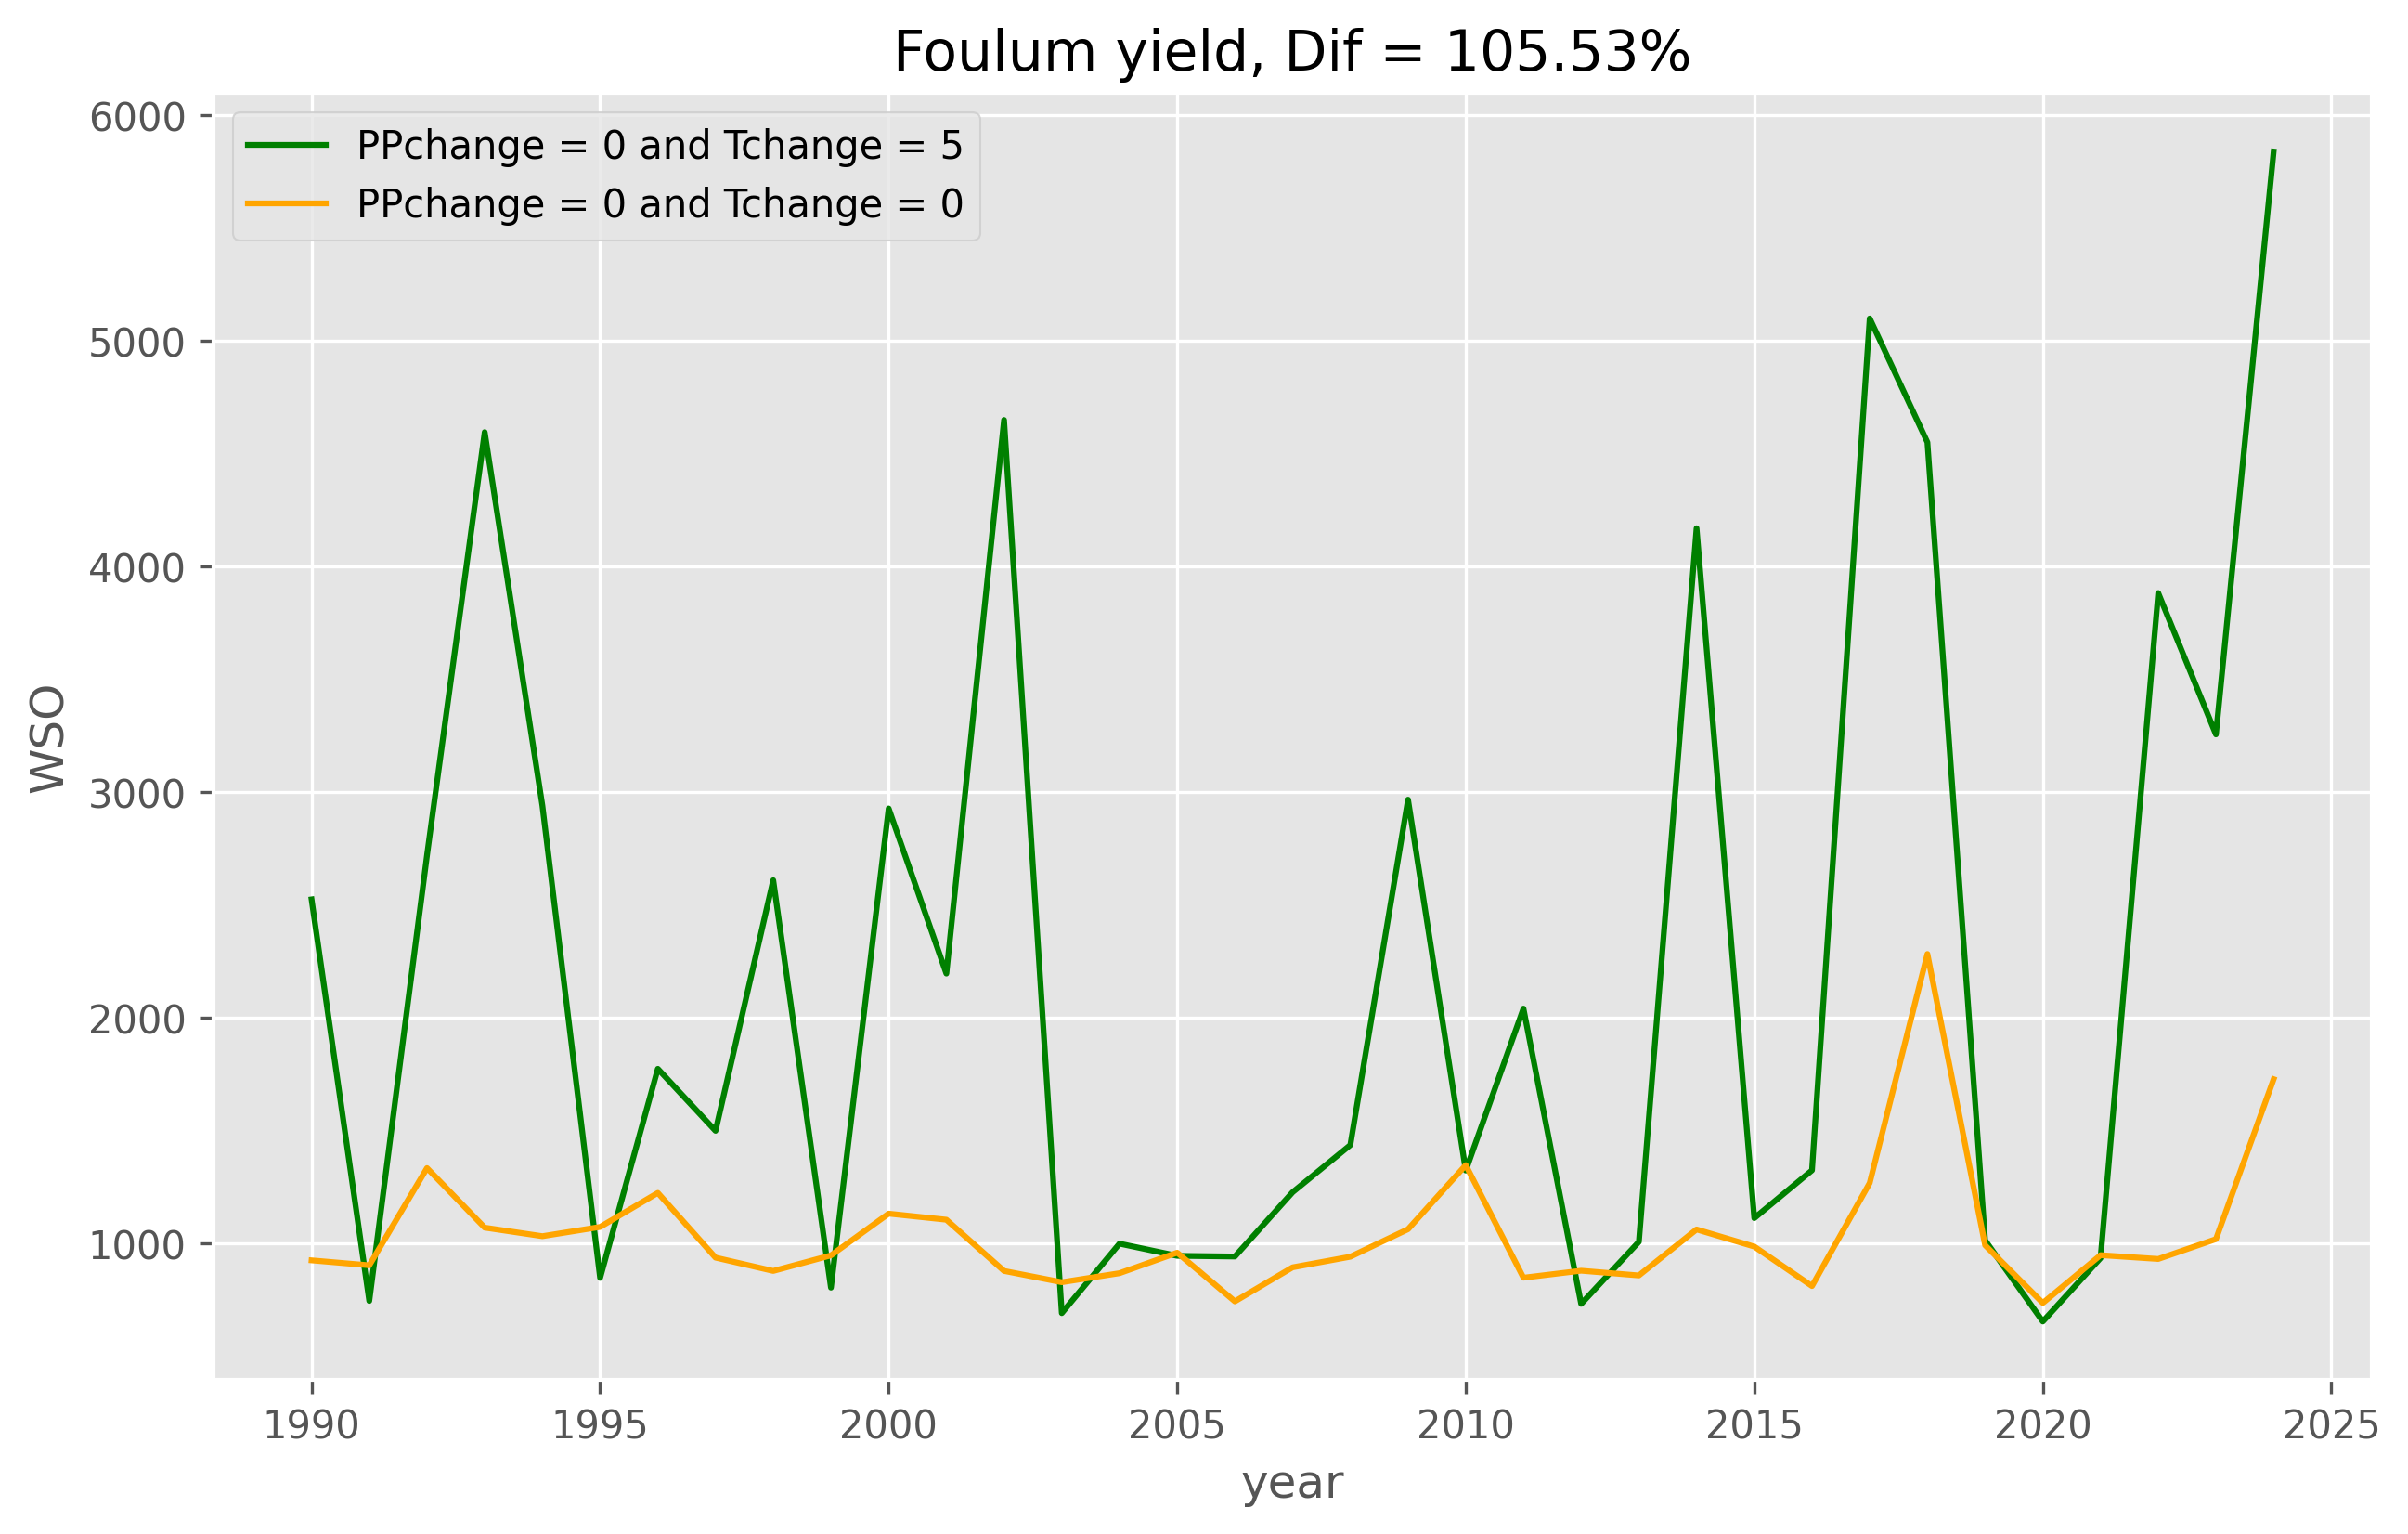

In [26]:
#just a test to compare with the surface plot
plt.figure(figsize=(10, 6), dpi = 300)
b = WSO_max.sel(PPstep=0, Tstep=5)
b.plot(label='PPchange = 0 and Tchange = 5', color='green')
a = WSO_max.sel(PPstep=0, Tstep=0)
a.plot(label='PPchange = 0 and Tchange = 0', color='orange')
dif = (b - a) / a * 100
dif2 = dif.mean(dim='year',  skipna=True)
plt.legend()
plt.title(f'{loc} yield, Dif = {dif2.values:.2f}%')

In [27]:
# Calculate percentage difference from baseline (0,0)
#percentage difference of the years that are not 0 in the baseline and in the future scenario

diff = (WSO_max - WSO_max_base.sel(PPstep=0, Tstep=0))/WSO_max_base.sel(PPstep=0, Tstep=0) * 100.0
# 2. Ensure both max_per_year and base max are non-zero 
diff = diff.where( 
    np.isfinite(diff) & 
    (WSO_max != 0) & 
    (WSO_max_base.sel(PPstep=0, Tstep=0) != 0) 
    )
#diff = diff.dropna(dim='year', how='all')  # Drop years with all NaNs
data = diff.mean(dim='year',  skipna=True)
#take the median of the diff
#data = diff.median(dim='year')


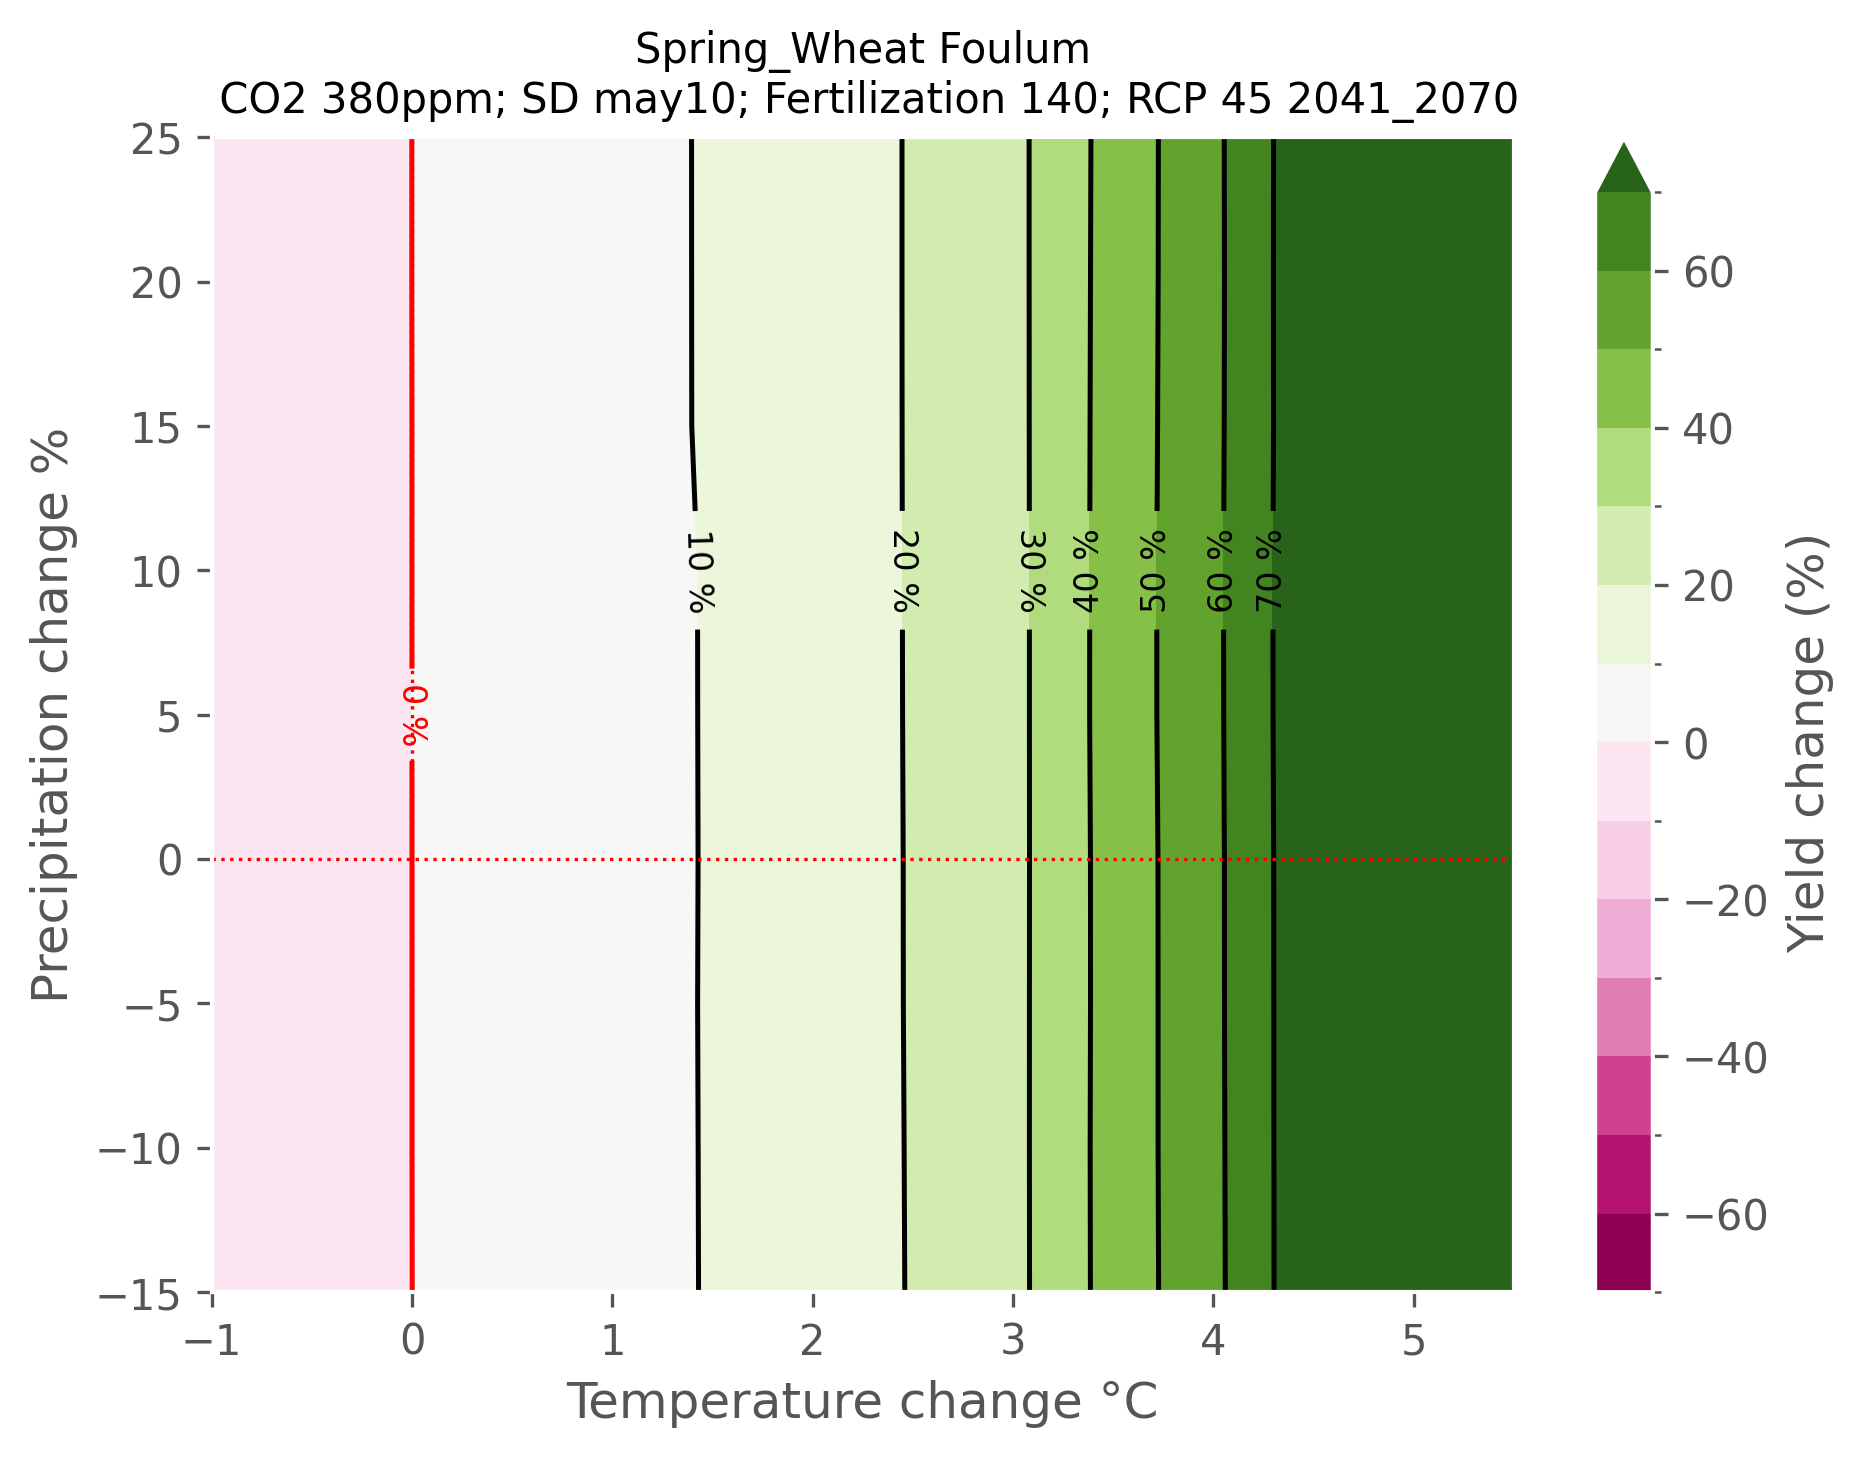

In [28]:
# Plot1:  IRS 
title_plot1 = f'{crop} {loc}\n CO2 {co2_data}ppm; SD {SD_data}; Fertilization {fert_data}; RCP {rcp} {climateperiod}' 
plot_name1 = f"results_plots/IRS_{crop}_{loc}_CO2{co2_data}_ppm_SD{SD_data}_Fert{fert_data}_RCP{rcp}_{climateperiod}_ShowClimate{show_climate}.png"

plt.figure(figsize=(7,5), dpi = 300)
contourf = data.plot.contourf(levels=15, cmap='PiYG', 
                              vmin = -70,
                              vmax = 70, #vmax= 7900,
                              cbar_kwargs={'label': 'Yield change (%)'})  # more levels = smoother
# Define contour levels
levels = np.linspace(-70, 70, 15)

# Default all black
colors = ["black"] * len(levels)

# If 0 is in levels, make it red
if 0 in levels:
    idx0 = list(levels).index(0)
    colors[idx0] = "red"
else:
    # Ensure 0 is included
    levels = np.sort(np.append(levels, 0))
    colors = ["black"] * len(levels)
    colors[list(levels).index(0)] = "red"

# Add isolines
contour = data.plot.contour(
    levels=levels,
    colors=colors,
    linewidths=1.2,
    linestyles='-',
    add_labels=False   # turn off auto-labels
)

# Label isolines with % sign
plt.clabel(
    contour,
    inline=True,
    fontsize=8,
    fmt='%1.0f %%'   # format labels as integers with % sign
)

plt.xlabel("Temperature change °C")
plt.ylabel("Precipitation change %")
plt.title(title_plot1, fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)

if show_climate:
    # KDE shading
    # Truncate the Greys colormap to avoid white
    def truncate_colormap(cmap, minval=0.4, maxval=0.9, n=100):
        return LinearSegmentedColormap.from_list(
            "trunc_greys", cmap(np.linspace(minval, maxval, n))
        )
    trunc_greys = truncate_colormap(plt.cm.Greys, 0.4, 0.9)
    ax = sns.kdeplot(
        x=df_changes['t_change'],
        y=df_changes['pp_change'],
        cmap=trunc_greys,   # use truncated greys
        fill=True, alpha=0.6,
        levels=[0.1, 0.25, 0.5, 0.75, 0.95, 1],
        thresh=0.0,
        common_norm=False
    )

    # --- Overlay CSV points ---
    plt.scatter(
        df_changes['t_change'],   # x-axis: temperature change
        df_changes['pp_change'],  # y-axis: precipitation change
        color="k", edgecolor="k", s=12, marker="o", alpha=0.4
    )

    # Add colorbar for probability scale
    # norm = plt.Normalize(vmin=0, vmax=1)
    # sm = plt.cm.ScalarMappable(cmap="Greys", norm=norm)
    # sm.set_array([])
    # cbar = plt.colorbar(sm, ax=ax)
    # cbar.set_label("Probability density (cumulative)")

# --- Add reference lines ---
plt.axhline(y=0, color='red', linestyle=':', linewidth=0.8)  # horizontal line at PP change = 0
plt.axvline(x=0, color='red', linestyle=':', linewidth=0.8)  # vertical line at T change = 0

plt.ylim(-15, 25)
plt.xlim(-1, 5.5)
plt.title(title_plot1, fontsize=10)
# Add grid
plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
plt.savefig(plot_name1, dpi=300)
plt.show()

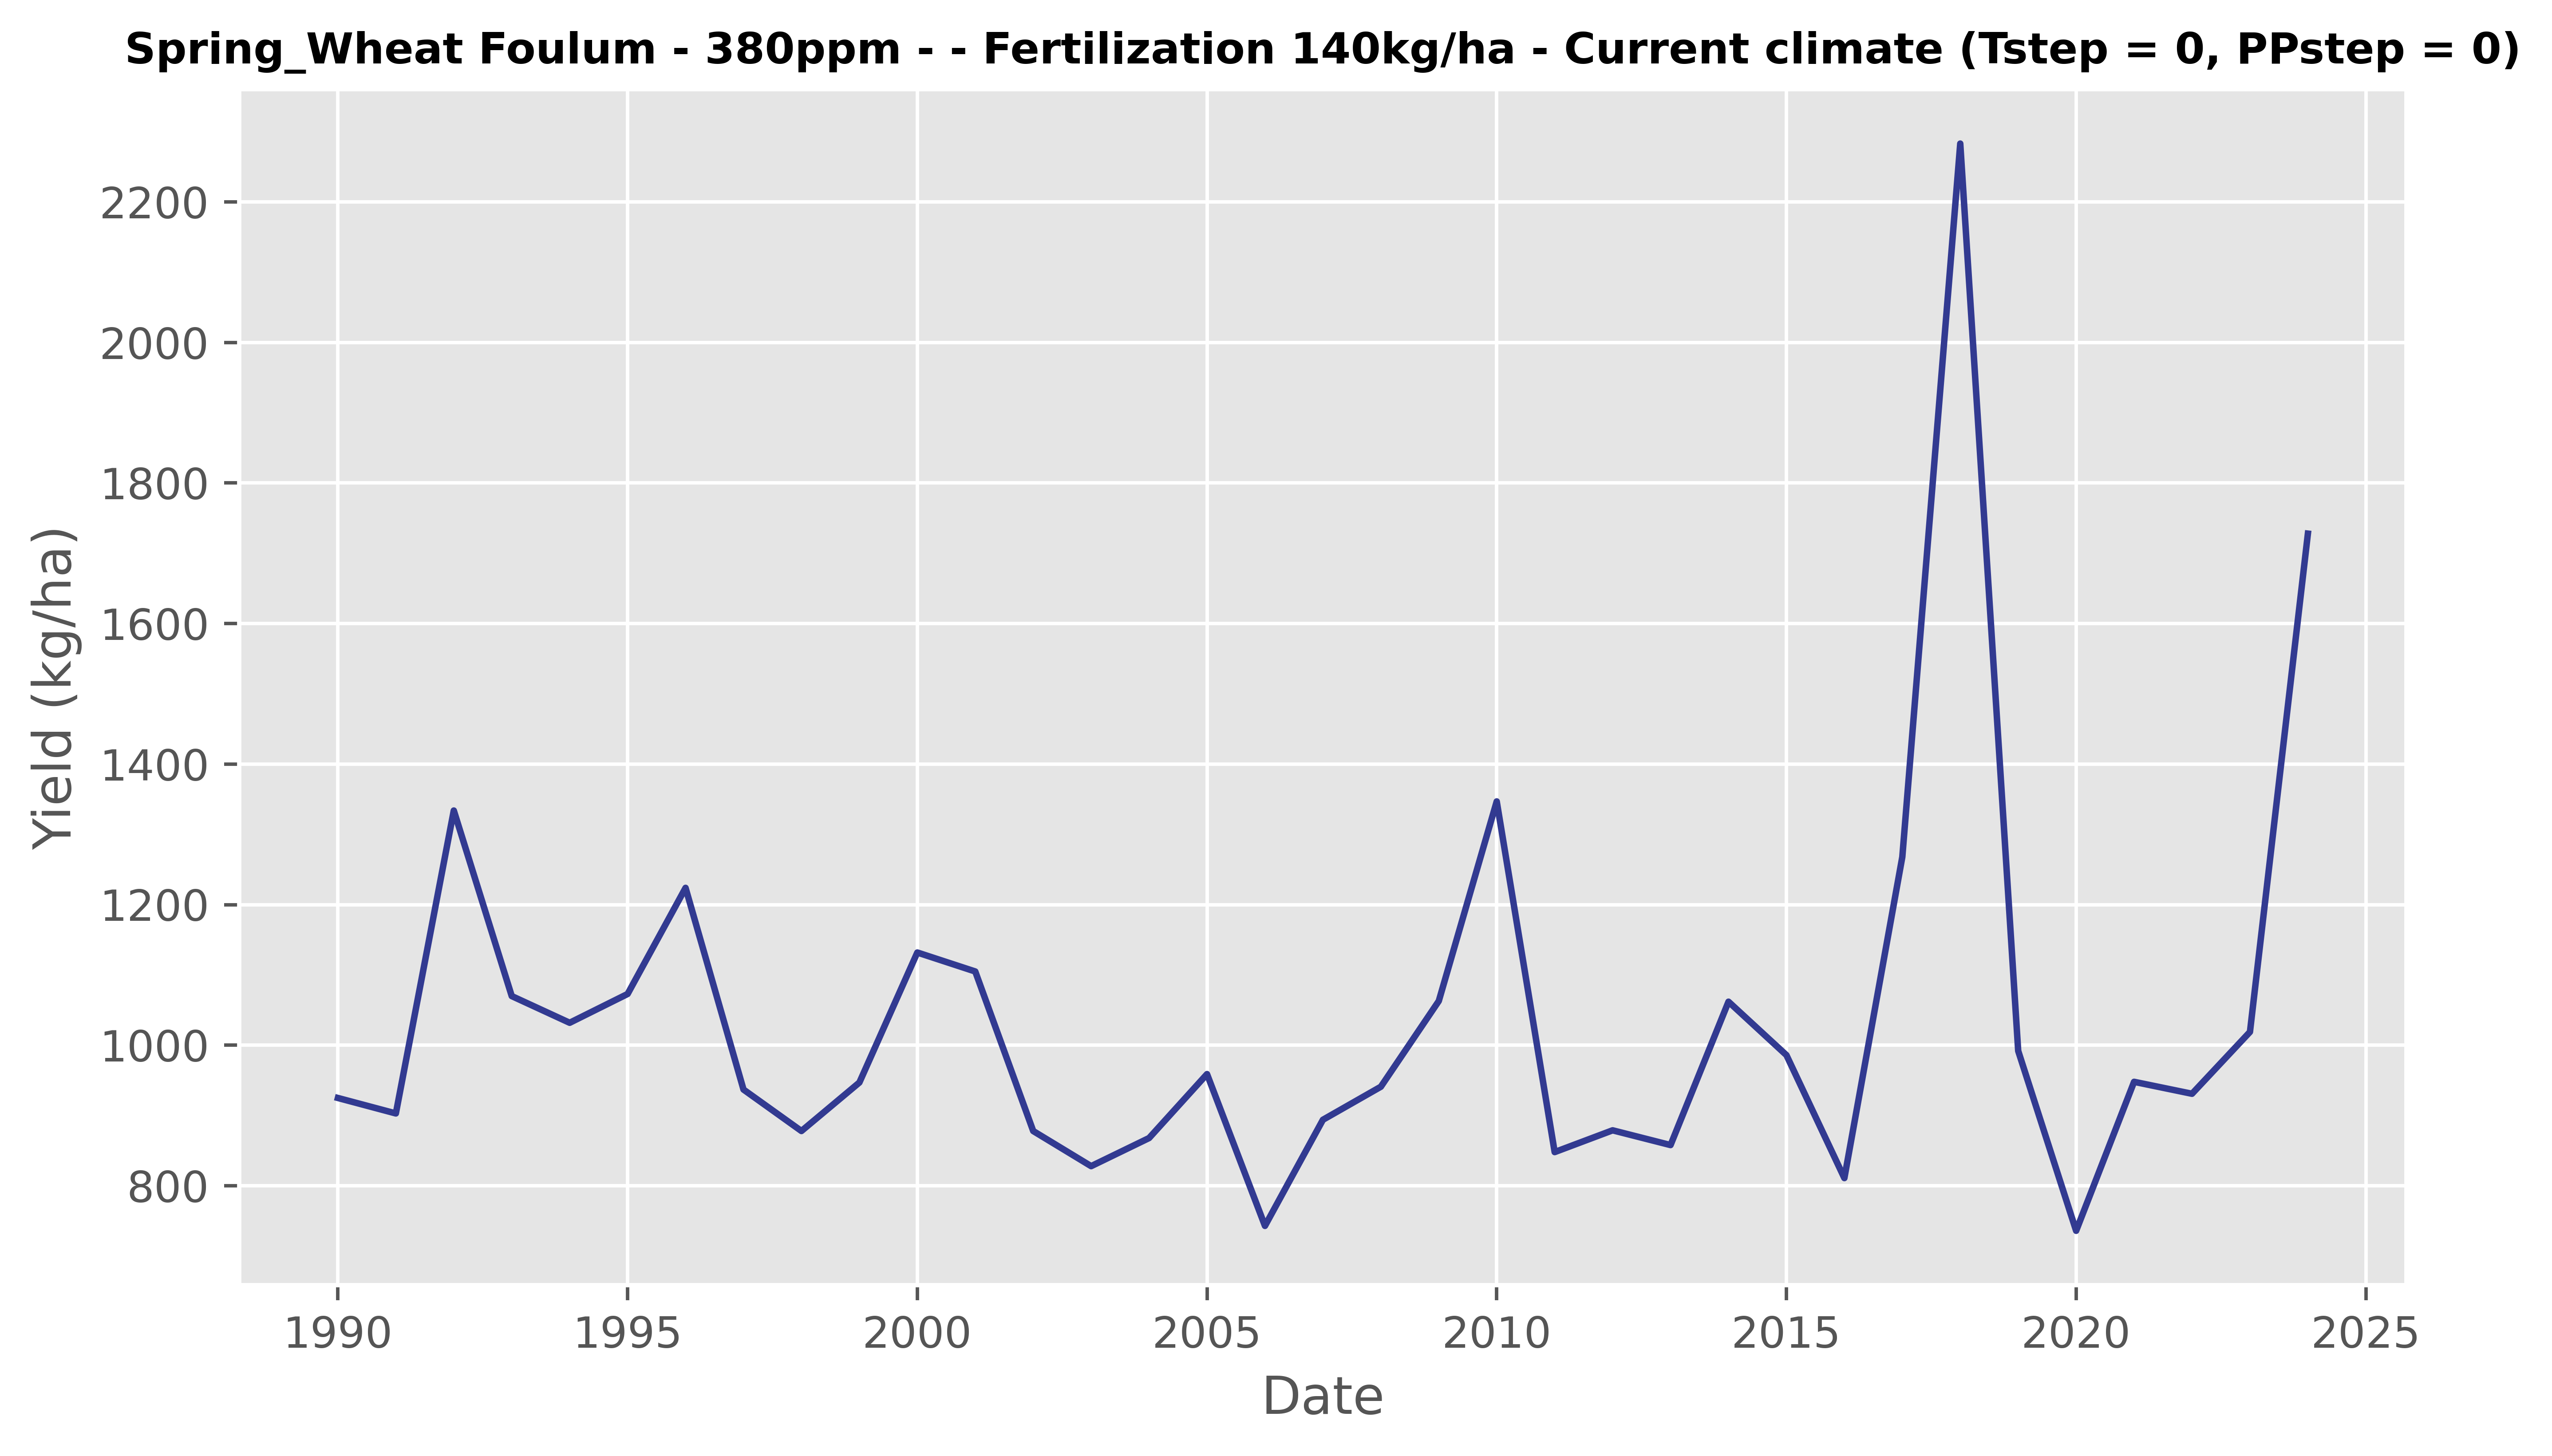

In [29]:
#plot 2: line plot of yield over time for different scenarios (Tstep, PPstep)
Tstep = 0
PPstep = 0
title_plot2 = f'{crop} {loc} - {co2_data}ppm - - Fertilization {fert_data}kg/ha - Current climate (Tstep = {Tstep}, PPstep = {PPstep})'
plot_name2 = f"results_plots/SERIE_{crop}_{loc}_CO2{co2_data}_ppm_SD{SD_data}_Fert{fert_data}_PPstep{PPstep}_Tstep{Tstep}.png"
plt.figure(figsize=(9,5), dpi = 700)
plt.plot(WSO_max.sel(Tstep=Tstep, PPstep=PPstep)["year"].values, WSO_max.sel(Tstep=Tstep, PPstep=PPstep).values, label='Rainfed cultivar', c = "#323a91")
plt.title(title_plot2,
          fontsize=10, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Yield (kg/ha)')
plt.savefig(plot_name2, dpi=300)


/var/folders/hh/pldtd_756y10knrbjp0j8jv80000gn/T/ipykernel_59603/2394348026.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([scenario1, scenario2, scenario3],


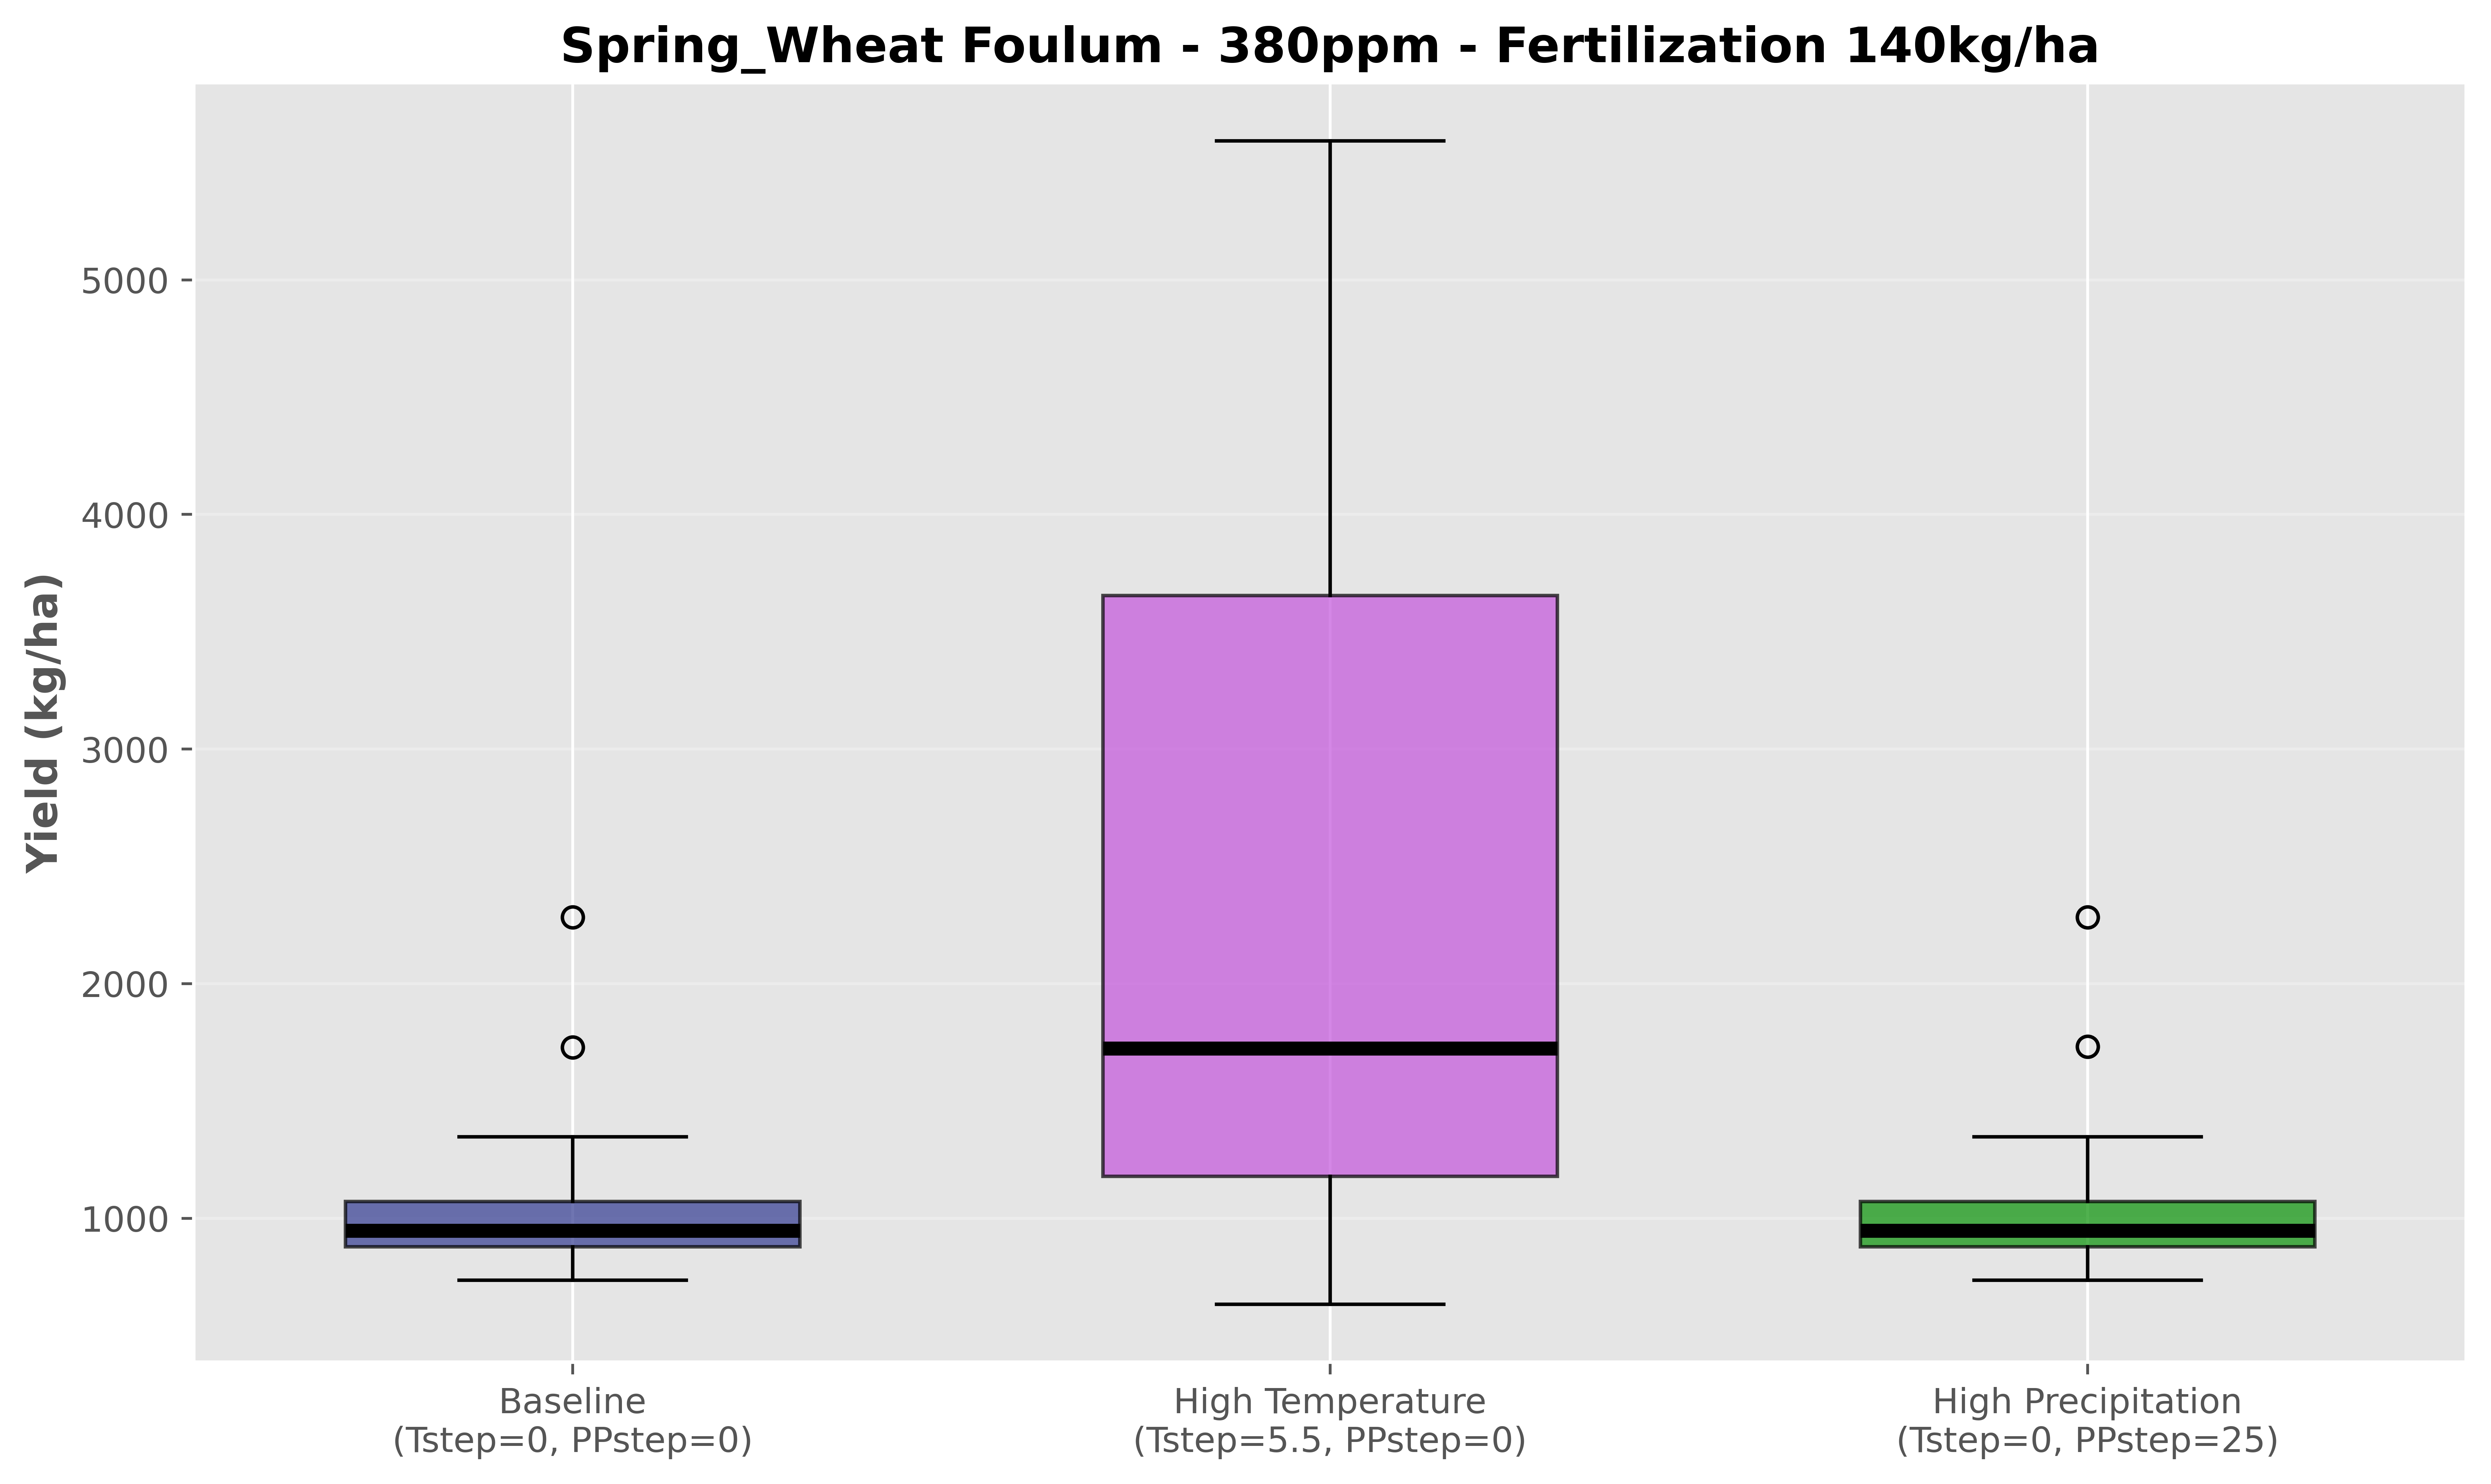

In [30]:
# Plot 3: boxplots of yearly max WSO for different scenarios (Tstep, PPstep)
# Extract yearly max values for each scenario
title_plot3 = f'{crop} {loc} - {co2_data}ppm - Fertilization {fert_data}kg/ha'
plot_name3 = f"results_plots/BOXPLOTS_{crop}_{loc}_CO2{co2_data}_ppm_SD{SD_data}_Fert{fert_data}.png"

scenario1 = WSO_max.sel(Tstep=0, PPstep=0).values
scenario2 = WSO_max.sel(Tstep=5.5, PPstep=0).values
scenario3 = WSO_max.sel(Tstep=0, PPstep=25).values

# Create single figure with all 3 boxplots
fig, ax = plt.subplots(figsize=(10, 6), dpi=700)

# Define colors for each boxplot
colors = ["#323a91", "#c354dc", "#079105"]  # Blue, Orange, Green
labels = ['Baseline\n(Tstep=0, PPstep=0)', 
          'High Temperature\n(Tstep=5.5, PPstep=0)', 
          'High Precipitation\n(Tstep=0, PPstep=25)']

# Create boxplots with different colors
bp = ax.boxplot([scenario1, scenario2, scenario3], 
                 labels=labels,
                 patch_artist=True,
                 widths=0.6,
                 medianprops=dict(color='black', linewidth=4))

# Color each boxplot
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize plot
ax.set_ylabel('Yield (kg/ha)', fontsize=12, fontweight='bold')
ax.set_title(title_plot3, 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(plot_name3, dpi=300)
plt.show()